# تشخیص هویت چهره با Eigenfaces و پیاده‌سازی PCA از صفر

در این پروژه می‌خواهیم PCA را با NumPy و بدون استفاده از PCA آماده پیاده‌سازی کنیم.

در این بخش تا محاسبه مقدارهای ویژه و ساخت Eigenfaceها پیش می‌رویم.

## گام ۱: دریافت و بررسی داده

برای دریافت دیتاست از sklearn استفاده می‌کنیم. محاسبات PCA را خودمان انجام می‌دهیم.

In [260]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

faces = fetch_olivetti_faces()
images = faces.images
labels = faces.target

print(f"faces.images.shape: {faces.images.shape},\nfaces.data.shape: {faces.data.shape},\nfaces.target.shape: {faces.target.shape}")

faces.images.shape: (400, 64, 64),
faces.data.shape: (400, 4096),
faces.target.shape: (400,)


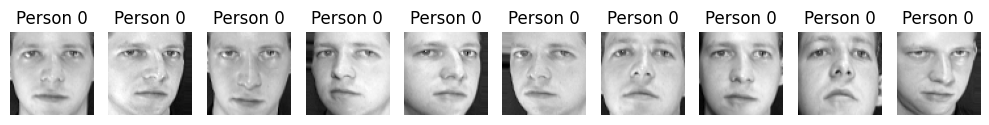

number of people: 40
images for each person: [10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10
 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10]


In [261]:
fig, axes = plt.subplots(1, 10, figsize=(10, 5))

for i in range(10):
    axes.flat[i].imshow(images[i], cmap='gray')
    axes.flat[i].set_title(f'Person {labels[i]}')
    axes.flat[i].axis('off')

plt.tight_layout()
plt.show()

print('number of people:', len(np.unique(labels)))
print('images for each person:', np.bincount(labels))

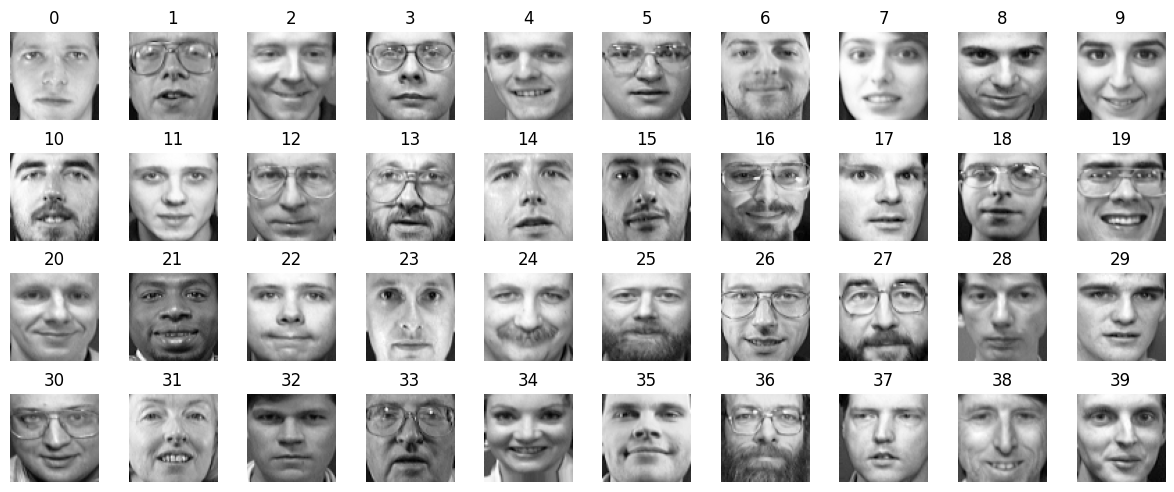

In [262]:
fig, axes = plt.subplots(4, 10, figsize=(12, 5))

for person in range(40):
    
    index = person * 10  
    
    ax = axes[person // 10, person % 10]
    
    ax.imshow(faces.images[index], cmap="gray")
    ax.axis("off")
    ax.set_title(f"{person}")

plt.tight_layout()
plt.show()

## گام ۲: جداسازی داده آموزش و آزمون

از هر شخص ۸ تصویر برای آموزش و ۲ تصویر برای آزمون انتخاب می‌کنیم.

عدد ۴۲ باعث می‌شود هر بار همان تقسیم قبلی را بگیریم.

In [263]:
rng = np.random.default_rng(42)

train_indices = []
test_indices = []

for person in np.unique(labels):
    person_indices = np.where(labels == person)[0]
    person_indices = rng.permutation(person_indices)

    train_indices.extend(person_indices[:8])
    test_indices.extend(person_indices[8:])

train_indices = np.array(train_indices)
test_indices = np.array(test_indices)

train_images = images[train_indices]
test_images = images[test_indices]
y_train = labels[train_indices]
y_test = labels[test_indices]

print('train images:', train_images.shape)
print('test images:', test_images.shape)

train images: (320, 64, 64)
test images: (80, 64, 64)


## گام ۳: تبدیل تصویر به بردار

هر تصویر ۶۴ در ۶۴ است. آن را به یک ردیف با ۴۰۹۶ عدد تبدیل می‌کنیم.

In [264]:
X_train = train_images.reshape(320, 4096).astype(np.float64)
X_test = test_images.reshape(80, 4096).astype(np.float64)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('8 train images for each person:', np.all(np.bincount(y_train) == 8))
print('2 test images for each person:', np.all(np.bincount(y_test) == 2))
print('train and test are separate:', len(np.intersect1d(train_indices, test_indices)) == 0)

X_train: (320, 4096)
X_test: (80, 4096)
8 train images for each person: True
2 test images for each person: True
train and test are separate: True


## گام ۴: محاسبه چهره میانگین و مرکزسازی

میانگین را فقط از داده آموزش حساب می‌کنیم. بعد همان میانگین را از آموزش و آزمون کم می‌کنیم.

```text
mean_face = sum of train images / number of train images
```

In [265]:
n_train = X_train.shape[0]

mean_face = np.sum(X_train, axis=0) / n_train

X_train_centered = X_train - mean_face
X_test_centered = X_test - mean_face

print(f"Shape of centered training data: {X_train_centered.shape}")
print(f"Shape of centered testing data: {X_test_centered.shape}")
print('mean after centering:', np.abs(X_train_centered.mean(axis=0)).max())

Shape of centered training data: (320, 4096)
Shape of centered testing data: (80, 4096)
mean after centering: 2.251671071817896e-16


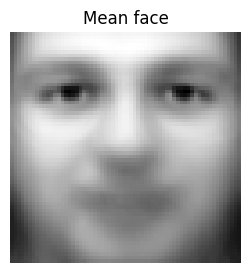

In [266]:
plt.figure(figsize=(3, 3))
plt.imshow(mean_face.reshape(64, 64), cmap='gray')
plt.title('Mean face')
plt.axis('off')
plt.show()

## گام ۵: پیاده‌سازی PCA از صفر

واریانس و کوواریانس را مستقیماً از تصویرهای train مرکز‌شده بررسی می‌کنیم. برای سبک‌ترشدن محاسبه، به‌جای covariance بزرگ پیکسل‌ها از Gram matrix استفاده می‌کنیم. توضیح کامل این انتخاب در [راهنمای آموزشی](docs/LEARNING_GUIDE.md) آمده است.

### ۵.۱ ساخت ماتریس Gram از داده‌های واقعی

ماتریس کوواریانس پیکسل‌ها ۴۰۹۶ در ۴۰۹۶ می‌شود. برای اینکه محاسبه سبک‌تر باشد، ماتریس Gram را می‌سازیم که ۳۲۰ در ۳۲۰ است.

```text
Gram = (X_centered @ X_centered.T) / (n - 1)
```

In [267]:
gram_matrix = (X_train_centered @ X_train_centered.T) / (n_train - 1)
total_variance = np.sum(X_train_centered ** 2) / (n_train - 1)

print('Gram matrix shape:', gram_matrix.shape)
print('symmetric:', np.allclose(gram_matrix, gram_matrix.T))

Gram matrix shape: (320, 320)
symmetric: True


In [268]:
# Check that the mean is computed only from training data
mean_from_train = np.mean(X_train, axis=0)

print(
    "Mean face is computed from training data:",
    np.allclose(mean_face, mean_from_train)
)

# Check that PCA components are built from training data
G_train = (
    X_train_centered @ X_train_centered.T
) / (n_train - 1)

print(
    "Gram matrix is based on training data:",
    np.allclose(gram_matrix, G_train)
)

Mean face is computed from training data: True
Gram matrix is based on training data: True


### ۵.۲ محاسبه مقدارهای ویژه و بردارهای ویژه

از `eigh` استفاده می‌کنیم چون ماتریس Gram متقارن است. این تابع مقدارها را از کوچک به بزرگ می‌دهد، پس آن‌ها را برعکس می‌کنیم.

In [269]:
eigenvalues, eigenvectors = np.linalg.eigh(gram_matrix)

order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

useful = eigenvalues > eigenvalues[0] * 1e-10
eigenvalues = eigenvalues[useful]
eigenvectors = eigenvectors[:, useful]

print('number of eigenvalues:', len(eigenvalues))
print('first 10 eigenvalues:')
print(np.round(eigenvalues[:10], 4))
is_descending = np.all(np.diff(eigenvalues) <= 0)

print("Eigenvalues sorted descending:", is_descending)

number of eigenvalues: 319
first 10 eigenvalues:
[18.9296 11.6741  6.1354  3.8166  2.8252  2.5447  1.9134  1.6315  1.6082
  1.303 ]
Eigenvalues sorted descending: True


## گام ۶: ساخت و نمایش Eigenfaceها

بردارهای ویژه فعلی ۳۲۰ عدد دارند. آن‌ها را به فضای ۴۰۹۶ پیکسلی برمی‌گردانیم و طول هر بردار را یک می‌کنیم.

In [270]:
eigenfaces = X_train_centered.T @ eigenvectors

lengths = np.sqrt(np.sum(eigenfaces ** 2, axis=0))
eigenfaces = eigenfaces / lengths

print('eigenfaces shape:', eigenfaces.shape)

eigenfaces shape: (4096, 319)


In [271]:
print(f"The shape of the each of the vector: {eigenfaces[:, 0].shape}")
print(f"The eigenfaces shape: {eigenfaces.shape}")

The shape of the each of the vector: (4096,)
The eigenfaces shape: (4096, 319)


In [272]:
center_is_ok = np.allclose(X_train_centered.mean(axis=0), 0, atol=1e-12)
values_are_sorted = np.all(np.diff(eigenvalues) <= 0)
variance_is_preserved = np.allclose(np.sum(eigenvalues), total_variance)

identity = np.eye(eigenfaces.shape[1])
vectors_are_orthogonal = np.allclose(
    eigenfaces.T @ eigenfaces, identity, atol=1e-10
)

print('centering is correct:', center_is_ok)
print('eigenvalues are sorted:', values_are_sorted)
print('eigenfaces are orthonormal:', vectors_are_orthogonal)
print('total variance:', round(total_variance, 4))
print('sum of eigenvalues:', round(np.sum(eigenvalues), 4))
print('variance is preserved:', variance_is_preserved)

centering is correct: True
eigenvalues are sorted: True
eigenfaces are orthonormal: True
total variance: 79.4179
sum of eigenvalues: 79.4179
variance is preserved: True


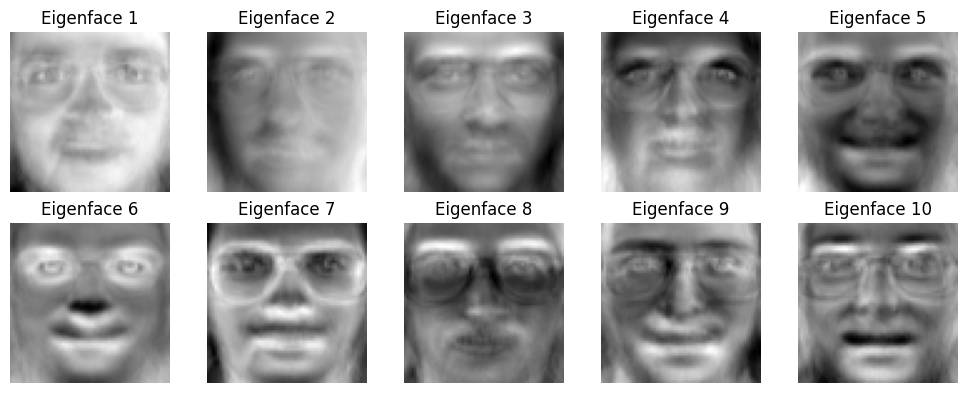

variance of first component: 23.84 %
variance of first 10 components: 65.96 %


In [273]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i in range(10):
    axes.flat[i].imshow(eigenfaces[:, i].reshape(64, 64), cmap='gray')
    axes.flat[i].set_title(f'Eigenface {i + 1}')
    axes.flat[i].axis('off')

plt.tight_layout()
plt.show()

variance_ratio = eigenvalues / np.sum(eigenvalues)
print('variance of first component:', round(variance_ratio[0] * 100, 2), '%')
print('variance of first 10 components:', round(np.sum(variance_ratio[:10]) * 100, 2), '%')

## پایان بخش‌های تکمیل‌شده

تا اینجا داده را جدا و مرکز کردیم، ماتریس Gram را ساختیم و Eigenfaceها را به دست آوردیم.

در بخش بعدی تصویرها را روی این بردارها می‌اندازیم و بازسازی و تشخیص هویت را انجام می‌دهیم.

## گام ۷: Projection و Reconstruction

در این بخش تصویرهای train و test را به فضای کم‌بعد می‌بریم و برای `k = 10, 50, 150` بازسازی می‌کنیم.

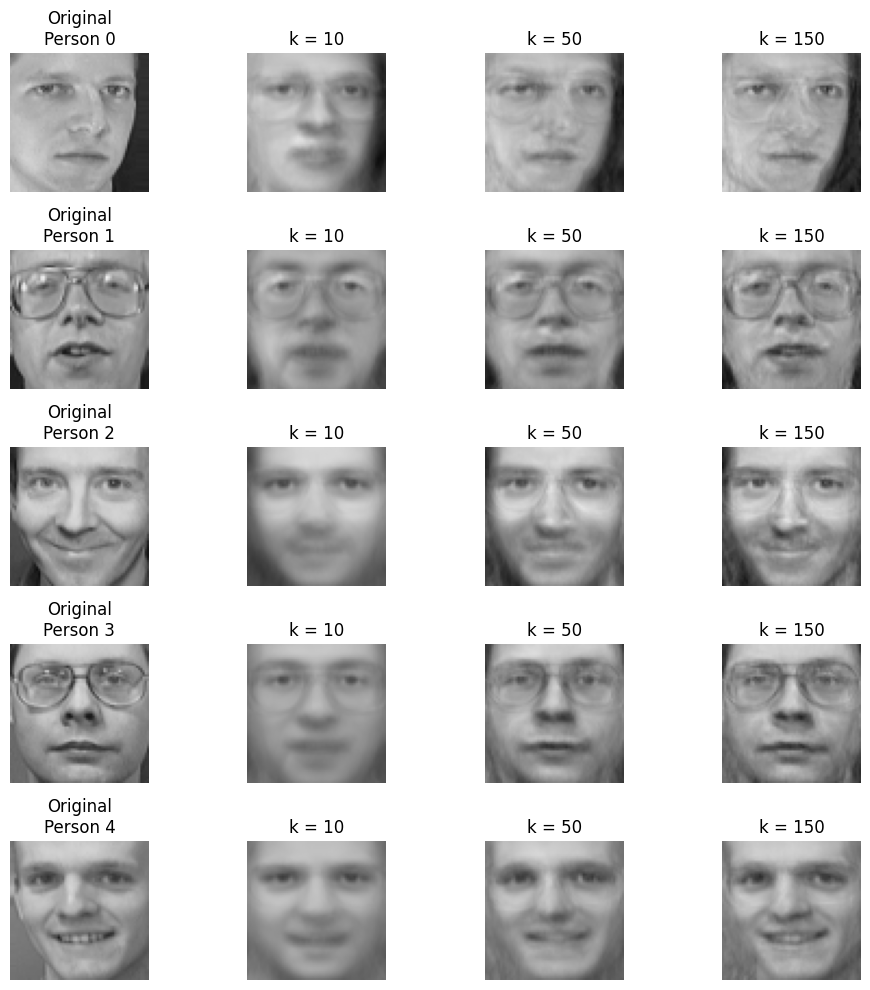

In [274]:
ks = [10, 50, 150]

sample_indices = [0, 2, 4, 6, 8]

fig, axes = plt.subplots(5, 4, figsize=(10, 10))

for row, test_index in enumerate(sample_indices):
    original_image = X_test[test_index]
    centered_image = X_test_centered[test_index]

    axes[row, 0].imshow(
        original_image.reshape(64, 64),
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[row, 0].set_title(f"Original\nPerson {y_test[test_index]}")
    axes[row, 0].axis("off")

    for column, k in enumerate(ks):
        selected_eigenfaces = eigenfaces[:, :k]

        # Projection
        weights = centered_image @ selected_eigenfaces

        # Reconstruction
        reconstructed_image = (
            weights @ selected_eigenfaces.T
            + mean_face
        )

        axes[row, column + 1].imshow(
            reconstructed_image.reshape(64, 64),
            cmap="gray",
            vmin=0,
            vmax=1
        )
        axes[row, column + 1].set_title(f"k = {k}")
        axes[row, column + 1].axis("off")

plt.tight_layout()
plt.show()

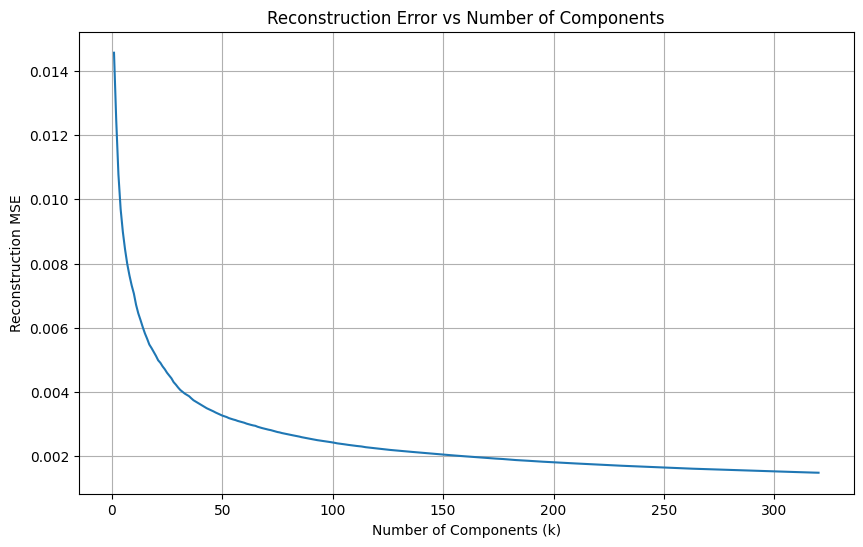

In [275]:
ks = range(1, 321)
reconstruction_errors = []

for k in ks:
    U_k = eigenfaces[:, :k]

    # Projection
    X_test_pca = X_test_centered @ U_k

    # Reconstruction
    X_test_reconstructed = X_test_pca @ U_k.T

    # Reconstruction MSE
    mse = np.mean(
        (X_test_centered - X_test_reconstructed) ** 2
    )

    reconstruction_errors.append(mse)

plt.figure(figsize=(10, 6))

plt.plot(
    ks,
    reconstruction_errors
)

plt.xlabel("Number of Components (k)")
plt.ylabel("Reconstruction MSE")
plt.title("Reconstruction Error vs Number of Components")
plt.grid(True)

plt.show()

In [276]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

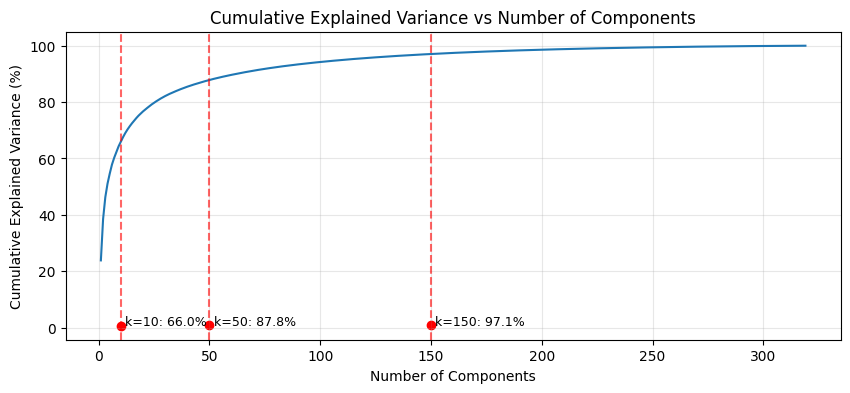

In [277]:
components = np.arange(1, len(cumulative_variance) + 1)

plt.figure(figsize=(10, 4))

plt.plot(components, cumulative_variance * 100)

for k in [10, 50, 150]:
    var_k = cumulative_variance[k - 1] * 100
    plt.axvline(k, color='r', linestyle='--', alpha=0.6)
    plt.scatter([k], [cumulative_variance[k - 1]], color='red')
    plt.text(k + 2, cumulative_variance[k - 1] - 0.05, f"k={k}: {var_k:.1f}%", fontsize=9)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Explained Variance vs Number of Components")
plt.grid(True, alpha=0.3)
plt.show()

In [278]:
for k in [10, 50, 150]:
    Q = eigenfaces[:, :k]

    unit_norm = np.allclose(
        np.linalg.norm(Q, axis=0),
        1
    )

    orthogonal = np.allclose(
        Q.T @ Q,
        np.eye(k)
    )

    print(f"k={k}")
    print("  Unit norm:", unit_norm)
    print("  Orthogonal:", orthogonal)
    print()

k=10
  Unit norm: True
  Orthogonal: True

k=50
  Unit norm: True
  Orthogonal: True

k=150
  Unit norm: True
  Orthogonal: True



## گام ۸: ارزیابی بازسازی و تشخیص هویت

در این بخش reconstruction error، نزدیک‌ترین همسایه، accuracy و نمونه‌های موفق و شکست را بررسی می‌کنیم.

In [279]:
import numpy as np
ks = [10, 50, 150]
reconstruction_errors = {}
for k in ks:
    U_k = eigenfaces[:, :k]
    errors = []
    for x in X_test:
        x_centered = x - mean_face
        # Projection
        z = x_centered @ U_k
        # Reconstruction
        x_reconstructed = z @ U_k.T + mean_face
        # MSE
        mse = np.mean((x - x_reconstructed) ** 2)
        errors.append(mse)
    reconstruction_errors[k] = np.mean(errors)
print(reconstruction_errors)

{10: np.float64(0.007065890200921701), 50: np.float64(0.003269112208657833), 150: np.float64(0.002055405653202975)}


**k=10**

In [280]:
k = 10

U_k = eigenfaces[:, :k]

X_train_pca = X_train_centered @ U_k
X_test_pca = X_test_centered @ U_k

print("X_train_pca shape:", X_train_pca.shape)
print("X_test_pca shape:", X_test_pca.shape)
print("--------------------------")
test_vec = X_test_pca[0]

distances = np.linalg.norm(X_train_pca - test_vec, axis=1)

nearest_idx = np.argmin(distances)

predicted_label = y_train[nearest_idx]

print("Nearest training index:", nearest_idx)
print("Predicted label:", predicted_label)
print("True label:", y_test[0])
print("--------------------------")
predictions = []
for test_vec in X_test_pca:
    distances = np.linalg.norm(X_train_pca - test_vec, axis=1)
    nearest_idx = np.argmin(distances)
    predicted_label = y_train[nearest_idx]
    predictions.append(predicted_label)
predictions = np.array(predictions)
accuracy = np.mean(predictions == y_test)
print("Accuracy:", accuracy)
print("--------------------------")
wrong_indices = np.where(predictions != y_test)[0]
print("Wrong predictions:")
for idx in wrong_indices:
    print(
        f"Test index: {idx} | "
        f"Predicted: {predictions[idx]} | "
        f"True: {y_test[idx]}"
    )

X_train_pca shape: (320, 10)
X_test_pca shape: (80, 10)
--------------------------
Nearest training index: 62
Predicted label: 7
True label: 0
--------------------------
Accuracy: 0.925
--------------------------
Wrong predictions:
Test index: 0 | Predicted: 7 | True: 0
Test index: 4 | Predicted: 37 | True: 2
Test index: 7 | Predicted: 22 | True: 3
Test index: 24 | Predicted: 22 | True: 12
Test index: 25 | Predicted: 39 | True: 12
Test index: 51 | Predicted: 16 | True: 25


In [281]:
correct_indices = np.where(predictions == y_test)[0]
print(correct_indices[:5])

[1 2 3 5 6]


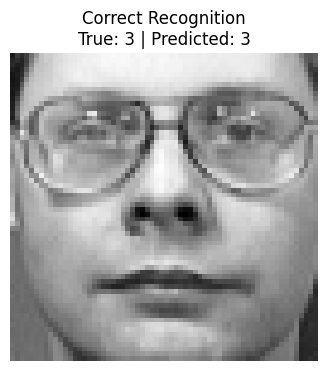

In [282]:
idx = 6

plt.figure(figsize=(4,4))
plt.imshow(X_test[idx].reshape(64, 64), cmap="gray")
plt.title(
    f"Correct Recognition\n"
    f"True: {y_test[idx]} | Predicted: {predictions[idx]}"
)
plt.axis("off")
plt.show()

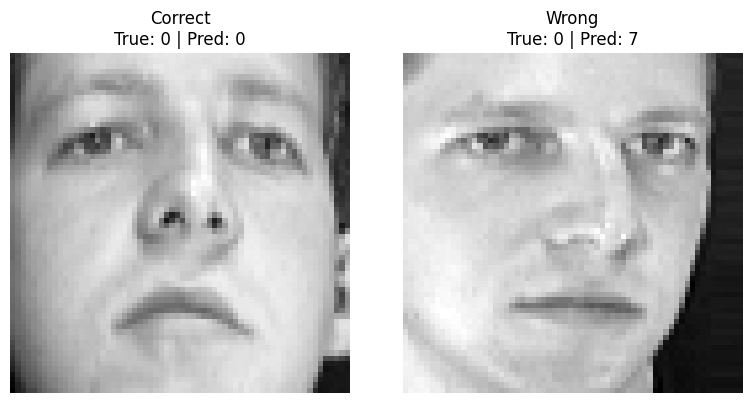

In [283]:
correct_idx = 1
wrong_idx = 0

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Correct
axes[0].imshow(X_test[correct_idx].reshape(64, 64), cmap="gray")
axes[0].set_title(
    f"Correct\nTrue: {y_test[correct_idx]} | "
    f"Pred: {predictions[correct_idx]}"
)
axes[0].axis("off")

# Wrong
axes[1].imshow(X_test[wrong_idx].reshape(64, 64), cmap="gray")
axes[1].set_title(
    f"Wrong\nTrue: {y_test[wrong_idx]} | "
    f"Pred: {predictions[wrong_idx]}"
)
axes[1].axis("off")

plt.tight_layout()
plt.show()

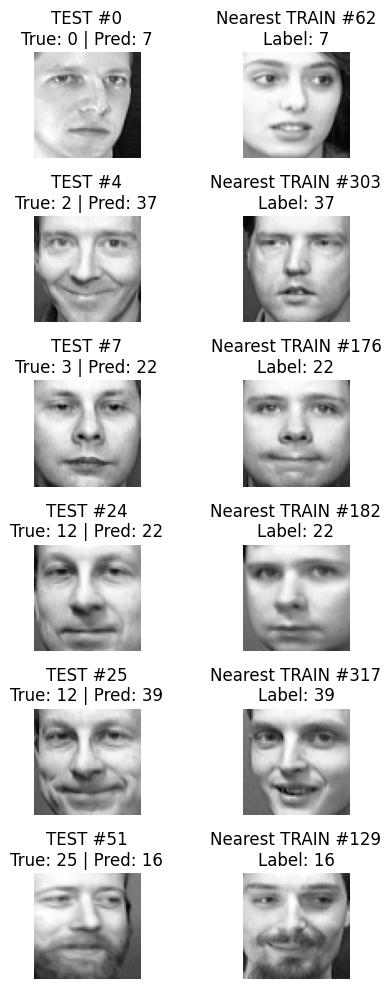

In [284]:
wrong_indices = np.where(predictions != y_test)[0]
fig, axes = plt.subplots(len(wrong_indices), 2, figsize=(5, 10))
for row, test_idx in enumerate(wrong_indices):
    test_image = X_test[test_idx].reshape(64, 64)
    test_vec = X_test_pca[test_idx]
    distances = np.linalg.norm(X_train_pca - test_vec, axis=1)
    nearest_idx = np.argmin(distances)
    train_image = X_train[nearest_idx].reshape(64, 64)
    axes[row, 0].imshow(test_image, cmap="gray")
    axes[row, 0].set_title(
        f"TEST #{test_idx}\n"
        f"True: {y_test[test_idx]} | Pred: {predictions[test_idx]}"
    )
    axes[row, 0].axis("off")
    axes[row, 1].imshow(train_image, cmap="gray")
    axes[row, 1].set_title(
        f"Nearest TRAIN #{nearest_idx}\n"
        f"Label: {y_train[nearest_idx]}"
    )
    axes[row, 1].axis("off")
plt.tight_layout()
plt.show()

**k=50**

In [285]:
k = 50

U_k = eigenfaces[:, :k]

X_train_pca = X_train_centered @ U_k
X_test_pca = X_test_centered @ U_k

print("X_train_pca shape:", X_train_pca.shape)
print("X_test_pca shape:", X_test_pca.shape)
print("--------------------------")
test_vec = X_test_pca[0]

distances = np.linalg.norm(X_train_pca - test_vec, axis=1)

nearest_idx = np.argmin(distances)

predicted_label = y_train[nearest_idx]

print("Nearest training index:", nearest_idx)
print("Predicted label:", predicted_label)
print("True label:", y_test[0])
print("--------------------------")
predictions = []
for test_vec in X_test_pca:
    distances = np.linalg.norm(X_train_pca - test_vec, axis=1)
    nearest_idx = np.argmin(distances)
    predicted_label = y_train[nearest_idx]
    predictions.append(predicted_label)
predictions = np.array(predictions)
accuracy = np.mean(predictions == y_test)
print("Accuracy:", accuracy)
print("--------------------------")
wrong_indices = np.where(predictions != y_test)[0]
print("Wrong predictions:")
for idx in wrong_indices:
    print(
        f"Test index: {idx} | "
        f"Predicted: {predictions[idx]} | "
        f"True: {y_test[idx]}"
    )

X_train_pca shape: (320, 50)
X_test_pca shape: (80, 50)
--------------------------
Nearest training index: 62
Predicted label: 7
True label: 0
--------------------------
Accuracy: 0.9375
--------------------------
Wrong predictions:
Test index: 0 | Predicted: 7 | True: 0
Test index: 16 | Predicted: 39 | True: 8
Test index: 24 | Predicted: 22 | True: 12
Test index: 25 | Predicted: 39 | True: 12
Test index: 30 | Predicted: 0 | True: 15


In [286]:
correct_indices = np.where(predictions == y_test)[0]
print(correct_indices[:5])

[1 2 3 4 5]


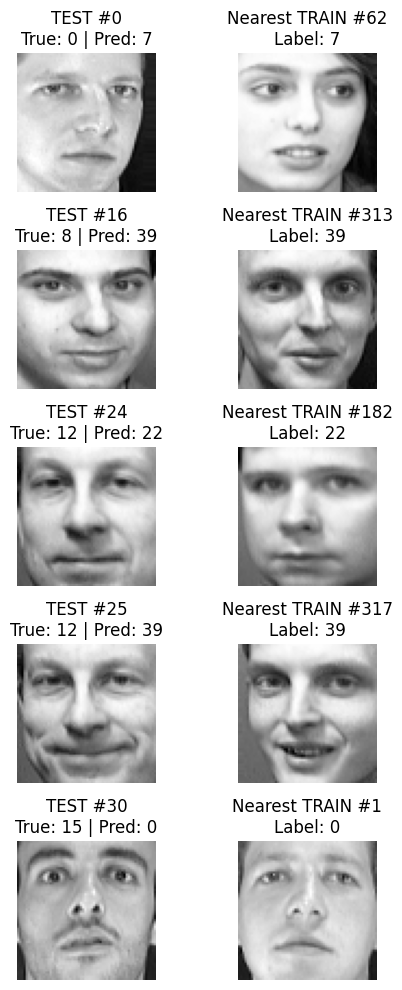

In [287]:
wrong_indices = np.where(predictions != y_test)[0]
fig, axes = plt.subplots(len(wrong_indices), 2, figsize=(5, 10))
for row, test_idx in enumerate(wrong_indices):
    test_image = X_test[test_idx].reshape(64, 64)
    test_vec = X_test_pca[test_idx]
    distances = np.linalg.norm(X_train_pca - test_vec, axis=1)
    nearest_idx = np.argmin(distances)
    train_image = X_train[nearest_idx].reshape(64, 64)
    axes[row, 0].imshow(test_image, cmap="gray")
    axes[row, 0].set_title(
        f"TEST #{test_idx}\n"
        f"True: {y_test[test_idx]} | Pred: {predictions[test_idx]}"
    )
    axes[row, 0].axis("off")
    axes[row, 1].imshow(train_image, cmap="gray")
    axes[row, 1].set_title(
        f"Nearest TRAIN #{nearest_idx}\n"
        f"Label: {y_train[nearest_idx]}"
    )
    axes[row, 1].axis("off")
plt.tight_layout()
plt.show()

**k=150**

In [288]:
k = 150

U_k = eigenfaces[:, :k]

X_train_pca = X_train_centered @ U_k
X_test_pca = X_test_centered @ U_k

print("X_train_pca shape:", X_train_pca.shape)
print("X_test_pca shape:", X_test_pca.shape)
print("--------------------------")
test_vec = X_test_pca[0]

distances = np.linalg.norm(X_train_pca - test_vec, axis=1)

nearest_idx = np.argmin(distances)

predicted_label = y_train[nearest_idx]

print("Nearest training index:", nearest_idx)
print("Predicted label:", predicted_label)
print("True label:", y_test[0])
print("--------------------------")
predictions = []
for test_vec in X_test_pca:
    distances = np.linalg.norm(X_train_pca - test_vec, axis=1)
    nearest_idx = np.argmin(distances)
    predicted_label = y_train[nearest_idx]
    predictions.append(predicted_label)
predictions = np.array(predictions)
accuracy = np.mean(predictions == y_test)
print("Accuracy:", accuracy)
print("--------------------------")
wrong_indices = np.where(predictions != y_test)[0]
print("Wrong predictions:")
for idx in wrong_indices:
    print(
        f"Test index: {idx} | "
        f"Predicted: {predictions[idx]} | "
        f"True: {y_test[idx]}"
    )

X_train_pca shape: (320, 150)
X_test_pca shape: (80, 150)
--------------------------
Nearest training index: 62
Predicted label: 7
True label: 0
--------------------------
Accuracy: 0.9375
--------------------------
Wrong predictions:
Test index: 0 | Predicted: 7 | True: 0
Test index: 16 | Predicted: 39 | True: 8
Test index: 24 | Predicted: 22 | True: 12
Test index: 25 | Predicted: 39 | True: 12
Test index: 30 | Predicted: 0 | True: 15


In [289]:
correct_indices = np.where(predictions == y_test)[0]
print(correct_indices[:5])

[1 2 3 4 5]


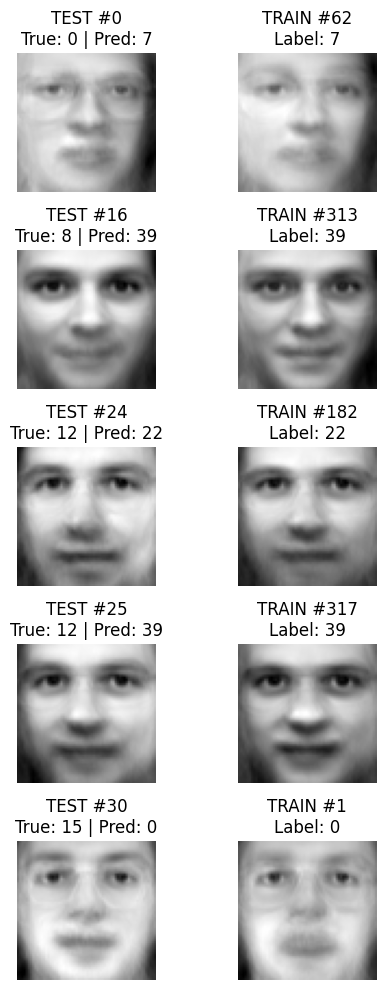

In [290]:
wrong_indices = np.where(predictions != y_test)[0]

k = 10
U_k = eigenfaces[:, :k]

fig, axes = plt.subplots(len(wrong_indices), 2, figsize=(5, 10))

for row, test_idx in enumerate(wrong_indices):


    x_centered = X_test_centered[test_idx]

    z = x_centered @ U_k
    x_reconstructed = z @ U_k.T + mean_face

    test_vec = X_test_pca[test_idx]

    distances = np.linalg.norm(
        X_train_pca - test_vec,
        axis=1
    )

    nearest_idx = np.argmin(distances)


    train_centered = X_train_centered[nearest_idx]

    train_z = train_centered @ U_k
    train_reconstructed = train_z @ U_k.T + mean_face

    axes[row, 0].imshow(
        x_reconstructed.reshape(64, 64),
        cmap="gray"
    )
    axes[row, 0].set_title(
        f"TEST #{test_idx}\n"
        f"True: {y_test[test_idx]} | Pred: {predictions[test_idx]}"
    )
    axes[row, 0].axis("off")


    axes[row, 1].imshow(
        train_reconstructed.reshape(64, 64),
        cmap="gray"
    )
    axes[row, 1].set_title(
        f"TRAIN #{nearest_idx}\n"
        f"Label: {y_train[nearest_idx]}"
    )
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

## گام ۹: مقایسه حداقلی با SVD

در این بخش نتیجه مسیر eigendecomposition را با `numpy.linalg.svd` کنترل می‌کنیم.

In [291]:
U, S, Vt = np.linalg.svd(
    X_train_centered,
    full_matrices=False
)
print("U shape:", U.shape)
print("S shape:", S.shape)
print("Vt shape:", Vt.shape)
print(Vt[:3].shape)

U shape: (320, 320)
S shape: (320,)
Vt shape: (320, 4096)
(3, 4096)


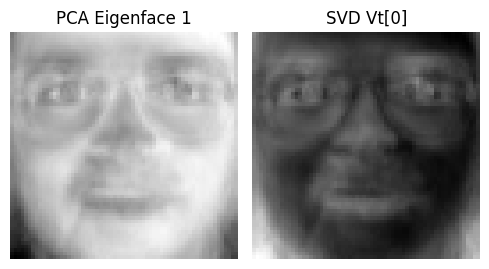

In [292]:
pca_component = eigenfaces[:, 0].reshape(64, 64)
svd_component = Vt[0].reshape(64, 64)

fig, axes = plt.subplots(1, 2, figsize=(5, 5))

axes[0].imshow(pca_component, cmap="gray")
axes[0].set_title("PCA Eigenface 1")
axes[0].axis("off")

axes[1].imshow(svd_component, cmap="gray")
axes[1].set_title("SVD Vt[0]")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [293]:
print(np.linalg.norm(eigenfaces[:, 0] - Vt[0]))
print(np.linalg.norm(eigenfaces[:, 0] + Vt[0]))

2.0
1.965632208077782e-15


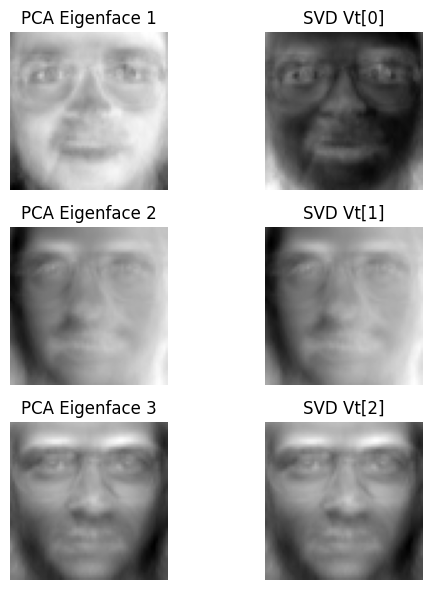

In [294]:
fig, axes = plt.subplots(3, 2, figsize=(6, 6))

for i in range(3):
    pca_face = eigenfaces[:, i].reshape(64, 64)

    svd_face = Vt[i].reshape(64, 64)

    axes[i, 0].imshow(pca_face, cmap="gray")
    axes[i, 0].set_title(f"PCA Eigenface {i+1}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(svd_face, cmap="gray")
    axes[i, 1].set_title(f"SVD Vt[{i}]")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [295]:
for k in [10, 50, 150]:
    Q_pca = eigenfaces[:, :k]
    Q_svd = Vt[:k].T

    P_pca = Q_pca @ Q_pca.T
    P_svd = Q_svd @ Q_svd.T

    difference = np.linalg.norm(P_pca - P_svd)

    print(f"k={k} | Subspace difference = {difference}")

k=10 | Subspace difference = 7.216134955003142e-14
k=50 | Subspace difference = 5.070406079761481e-14
k=150 | Subspace difference = 5.004910024216224e-13


In [296]:
k = 10

Q_pca = eigenfaces[:, :k]
Q_svd = Vt[:k].T

In [297]:
x = X_test[0]
x_centered = x - mean_face

# PCA reconstruction
x_pca = x_centered @ Q_pca @ Q_pca.T + mean_face

# SVD reconstruction
x_svd = x_centered @ Q_svd @ Q_svd.T + mean_face

print("PCA shape:", x_pca.shape)
print("SVD shape:", x_svd.shape)

PCA shape: (4096,)
SVD shape: (4096,)


In [298]:
difference = np.linalg.norm(x_pca - x_svd)
print("Reconstruction difference:", difference)

Reconstruction difference: 1.2876440635113186e-13


In [299]:
for k in [10, 50, 150]:

    Q_pca = eigenfaces[:, :k]
    Q_svd = Vt[:k].T

    differences = []

    for x in X_test:
        x_centered = x - mean_face

        # PCA reconstruction
        x_pca = x_centered @ Q_pca @ Q_pca.T + mean_face

        # SVD reconstruction
        x_svd = x_centered @ Q_svd @ Q_svd.T + mean_face

        # Difference between reconstructions
        diff = np.linalg.norm(x_pca - x_svd)
        differences.append(diff)

    mean_difference = np.mean(differences)

    print(f"k={k} | Mean reconstruction difference = {mean_difference}")

k=10 | Mean reconstruction difference = 7.15542359150944e-14
k=50 | Mean reconstruction difference = 3.2058576428817274e-14
k=150 | Mean reconstruction difference = 9.116535301653078e-14


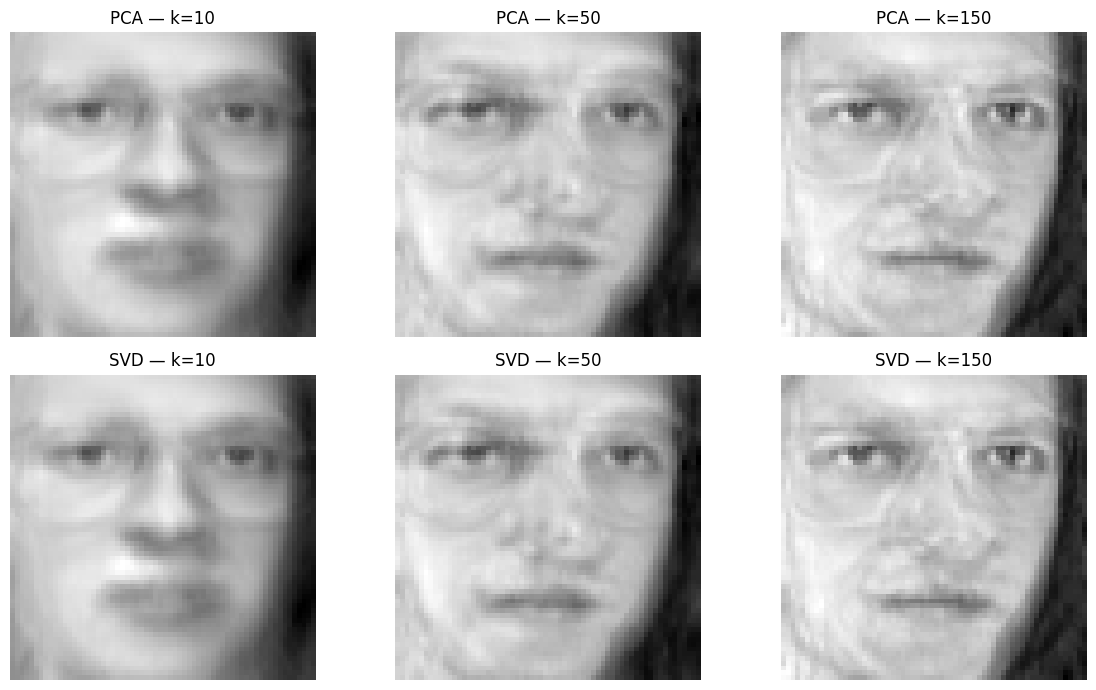

In [300]:
x = X_test[0]
x_centered = x - mean_face

ks = [10, 50, 150]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for j, k in enumerate(ks):

    Q_pca = eigenfaces[:, :k]
    Q_svd = Vt[:k].T

    # PCA reconstruction
    x_pca = x_centered @ Q_pca @ Q_pca.T + mean_face

    # SVD reconstruction
    x_svd = x_centered @ Q_svd @ Q_svd.T + mean_face

    # PCA image
    axes[0, j].imshow(x_pca.reshape(64, 64), cmap="gray")
    axes[0, j].set_title(f"PCA — k={k}")
    axes[0, j].axis("off")

    # SVD image
    axes[1, j].imshow(x_svd.reshape(64, 64), cmap="gray")
    axes[1, j].set_title(f"SVD — k={k}")
    axes[1, j].axis("off")

plt.tight_layout()
plt.show()

In [301]:
for k in [10, 50, 150]:

    U_k = eigenfaces[:, :k]

    X_train_pca = X_train_centered @ U_k
    X_test_pca = X_test_centered @ U_k

    print(f"k={k}")
    print("  Train compressed shape:", X_train_pca.shape)
    print("  Test compressed shape :", X_test_pca.shape)
    print()

k=10
  Train compressed shape: (320, 10)
  Test compressed shape : (80, 10)

k=50
  Train compressed shape: (320, 50)
  Test compressed shape : (80, 50)

k=150
  Train compressed shape: (320, 150)
  Test compressed shape : (80, 150)



## مأموریت اختصاصی تیم ۴: Euclidean در برابر Cosine

در این بخش دو معیار را با داده، مؤلفه‌ها و مقدار `k` یکسان مقایسه می‌کنیم.

## دموی تعاملی

در این بخش با انتخاب تصویر test، مقدار `k` و معیار شباهت، بازسازی و نزدیک‌ترین تصویر train را نمایش می‌دهیم.

## جمع‌بندی و محدودیت‌ها

در پایان به سؤال اصلی و سؤال تیم ۴ پاسخ می‌دهیم و محدودیت‌های واقعی آزمایش را می‌نویسیم.